In [1]:
from backtesting import PortfolioBacktester
from utils import compute_log_returns, plot_pearson_heatmap, plot_roi_bars, plot_sortino_bars

In [2]:
bt = PortfolioBacktester(
        portfolio_path="portfolio.json",
        start_date="2023-01-03",
    )
pv = bt.run()


Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records
Successfully downloaded 809 records


In [3]:
df = bt.get_full_dataframe()
df.head()

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX,portfolio_value,SP500
Date,,,,,,,,,,,,
2023-01-03,125.07,85.82,14.315,239.58,89.12,62.95,540.33,9.5,45.78,84.89,999620.705,3824.139893
2023-01-04,126.36,85.14,14.749,229.1,88.08,62.92,526.45,9.71,46.96,85.39,1000114.305,3852.969971
2023-01-05,125.02,83.12,14.265,222.31,86.2,62.2,528.52,10.13,46.75,87.73,994324.865,3808.100098
2023-01-06,129.62,86.08,14.859,224.93,87.34,63.4,521.42,10.28,47.31,88.41,1012163.775,3895.080078
2023-01-09,130.15,87.36,15.628,227.12,88.02,62.61,495.41,10.24,47.54,90.3,1017365.54,3892.090088


In [4]:
df = df.loc['2025-03-01':]
df


,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX,portfolio_value,SP500
Date,,,,,,,,,,,,
2025-03-03,238.03,205.02,114.06,388.49,167.01,72.32,473.41,13.14,77.17,54.68,2148763.21,5849.720215
2025-03-04,235.93,203.8,115.99,388.61,170.92,70.19,463.83,12.96,72.35,54.66,2145982.28,5778.149902
2025-03-05,235.74,208.36,117.3,401.02,173.02,70.08,474.2,12.97,72.96,56.65,2173347.89,5842.629883
2025-03-06,235.33,200.7,110.57,396.89,172.35,70.46,475.2,12.85,70.58,56.48,2108740.71,5738.520020
2025-03-07,239.07,199.25,112.69,393.31,173.86,71.43,486.52,12.97,70.46,58.34,2131874.1,5770.200195
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19,248.96,208.76,178.56,389.02,307.13,75.55,714.15,19.78,109.85,58.64,2965414.35,6606.490234
2026-03-20,247.99,205.37,172.7,381.87,301.0,74.75,706.95,18.8,109.52,57.63,2895071.09,6506.479980
2026-03-23,251.49,210.14,175.64,383.0,302.06,75.11,680.0,19.27,111.64,57.25,2930337.04,6581.000000


In [5]:
from utils import compute_log_returns
# All numeric columns (stocks + portfolio_value + SP500)
log_ret = compute_log_returns(df)
log_ret.head()

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX,portfolio_value,SP500
Date,,,,,,,,,,,,
2025-03-04,-0.008862,-0.005968,0.016779,0.000309,0.023142,-0.029895,-0.020444,-0.013793,-0.064495,-0.000366,-0.001295,-0.012310
2025-03-05,-0.000806,0.022128,0.011231,0.031435,0.012212,-0.001568,0.022111,0.000771,0.008396,0.03576,0.012671,0.011097
2025-03-06,-0.001741,-0.037456,-0.059086,-0.010352,-0.00388,0.005408,0.002107,-0.009295,-0.033165,-0.003005,-0.030178,-0.017980
2025-03-07,0.015768,-0.007251,0.018992,-0.009061,0.008723,0.013673,0.023542,0.009295,-0.001702,0.032401,0.010911,0.005505
2025-03-10,-0.049694,-0.023923,-0.051999,-0.034006,-0.047046,0.00028,0.018188,-0.014758,-0.044252,-0.02728,-0.037228,-0.027344


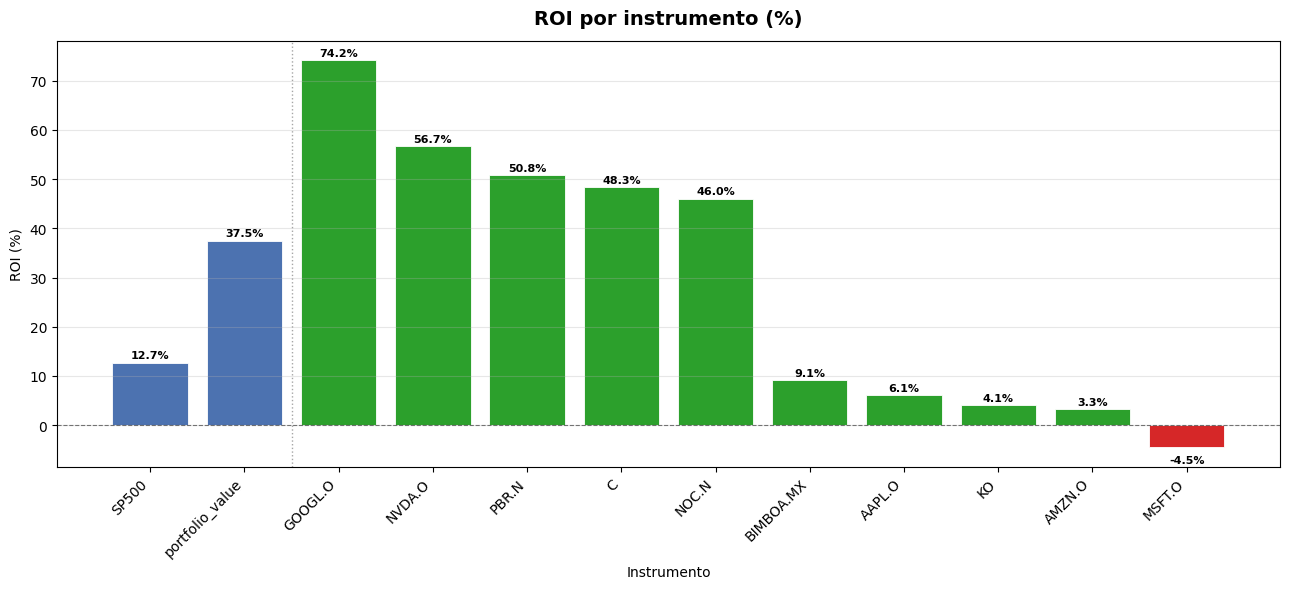

SP500              12.687439
portfolio_value    37.473329
GOOGL.O             74.19915
NVDA.O             56.654392
PBR.N              50.837139
C                  48.347804
NOC.N              46.006633
BIMBOA.MX           9.144111
AAPL.O              6.129479
KO                  4.051438
AMZN.O              3.263096
MSFT.O              -4.49175
dtype: Float64


In [8]:
# 2. Graficar ROI — S&P 500 y portfolio_value aparecen primero (azul)
roi = plot_roi_bars(df)
# Ver los valores numéricos ordenados
print(roi)

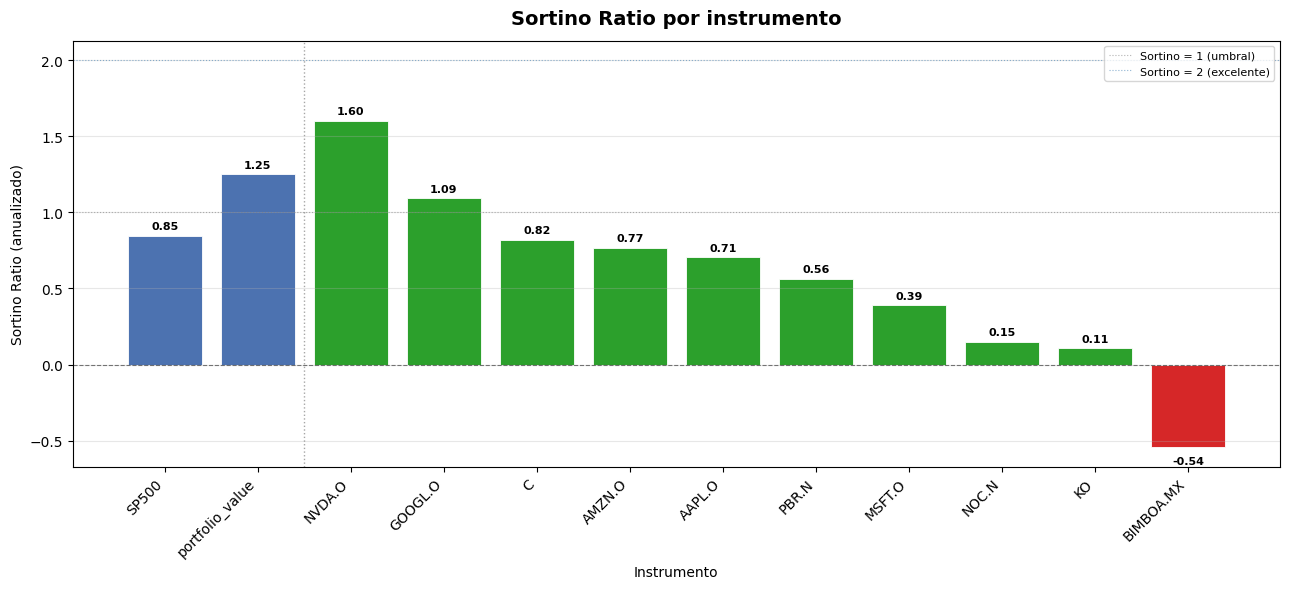

SP500              0.846186
portfolio_value    1.250126
NVDA.O             1.601051
GOOGL.O            1.090861
C                  0.819610
AMZN.O             0.768978
AAPL.O             0.705681
PBR.N              0.564181
MSFT.O             0.390256
NOC.N              0.148410
KO                 0.106209
BIMBOA.MX         -0.542684
dtype: float64


In [6]:
# Con tasa libre de riesgo del 4% anual (ej. T-Bills)
sortino = plot_sortino_bars(bt.get_full_dataframe(), risk_free_rate=0.04)
# Ver ranking numérico
print(sortino)